#### Imports and load data

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os, time, sys
sys.path.append("..")

from spikingjelly.activation_based import neuron, functional, surrogate
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler
import joblib

SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)

os.makedirs("../outputs", exist_ok=True)

# ── Load data (same as Day 1) ─────────────────────────────────────────
train_raw = pd.read_csv("../data/processed/train_features.csv",
                         index_col="date", parse_dates=True)
val_raw   = pd.read_csv("../data/processed/val_features.csv",
                         index_col="date", parse_dates=True)

TARGET_COL   = "target"
FEATURE_COLS = [c for c in train_raw.columns if c != TARGET_COL]
N_FEATURES   = len(FEATURE_COLS)
LOOKBACK     = 10
BATCH_SIZE   = 32

train_clean = train_raw[FEATURE_COLS + [TARGET_COL]].dropna()
val_clean   = val_raw[FEATURE_COLS + [TARGET_COL]].dropna()

# ── Scaler (fit on train only) ────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1), clip=True)
X_train = scaler.fit_transform(
    train_clean[FEATURE_COLS].values.astype(np.float32))
y_train = train_clean[TARGET_COL].values.astype(np.float32)

X_val = scaler.transform(
    val_clean[FEATURE_COLS].values.astype(np.float32))
y_val = val_clean[TARGET_COL].values.astype(np.float32)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}")
print(f"Features : {N_FEATURES}  |  Device : {DEVICE}")
print("✅ Data loaded")

Train : (1088, 9)  |  Val : (364, 9)
Features : 9  |  Device : cpu
✅ Data loaded


#### Reusable classes (copied from notebook 09)

In [ ]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, features, targets, lookback=10):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets  = torch.tensor(targets,  dtype=torch.float32)
        self.lookback = lookback
        self.valid_indices = list(range(lookback, len(features)))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        t = self.valid_indices[idx]
        return self.features[t - self.lookback : t], self.targets[t]


class BRICSLiquiditySNN(nn.Module):
    def __init__(self, n_features=9, hidden1=64, hidden2=32,
                 tau=2.0, v_threshold=0.1):
        super().__init__()
        self.n_features  = n_features
        self.hidden1     = hidden1
        self.hidden2     = hidden2
        self.tau         = tau
        self.v_threshold = v_threshold

        self.fc1  = nn.Linear(n_features, hidden1)
        self.bn1  = nn.BatchNorm1d(hidden1)
        self.lif1 = neuron.LIFNode(
            tau=tau, v_threshold=v_threshold,
            surrogate_function=surrogate.ATan(), detach_reset=True)

        self.fc2  = nn.Linear(hidden1, hidden2)
        self.bn2  = nn.BatchNorm1d(hidden2)
        self.lif2 = neuron.LIFNode(
            tau=tau, v_threshold=v_threshold,
            surrogate_function=surrogate.ATan(), detach_reset=True)

        self.fc3 = nn.Linear(hidden2, 1)
        self._init_weights()

    def _init_weights(self):
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        functional.reset_net(self)
        T = x.shape[1]
        spike_acc = torch.zeros(x.shape[0], self.hidden2,
                                device=x.device, dtype=x.dtype)
        for t in range(T):
            x_t = x[:, t, :]
            out = self.lif1(self.bn1(self.fc1(x_t)))
            out = self.lif2(self.bn2(self.fc2(out)))
            spike_acc += out
        return self.fc3(spike_acc / T)   # raw logit

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def get_spike_rate(self, loader, device, n_batches=10):
        """Measure mean spike rate across n_batches."""
        self.eval()  # In this evalution mode no new things is learned, it completely reply on lerned knowledge
        rates = []
        for i, (X_batch, _) in enumerate(loader):
            if i >= n_batches:     # Stops after the requested number of batches
                break
            X_batch = X_batch.to(device)
            functional.reset_net(self)  # Clears the internal state of the spiking neurons before processing this batch
            T = X_batch.shape[1]  # Gets the number of time steps in the input sequence, lookback = 10 so T = 10
            acc1 = torch.zeros(X_batch.shape[0], self.hidden1, device=device)
            acc2 = torch.zeros(X_batch.shape[0], self.hidden2, device=device)
            with torch.no_grad():  # Tells PyTorch not to track gradients
                for t in range(T):
                    x_t = X_batch[:, t, :]
                    s1  = self.lif1(self.bn1(self.fc1(x_t)))
                    s2  = self.lif2(self.bn2(self.fc2(s1)))
                    acc1 += s1   # Adds the spikes from layer 1 to the running total.
                    acc2 += s2   # Adds the spikes from layer 2 to the running total.
            r1 = (acc1 / T).mean().item()
            r2 = (acc2 / T).mean().item()
            rates.append((r1 + r2) / 2)
        return float(np.mean(rates))


# ── DataLoaders ───────────────────────────────────────────────────────
train_ds = TimeSeriesDataset(X_train, y_train, LOOKBACK)
val_ds   = TimeSeriesDataset(X_val,   y_val,   LOOKBACK)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

# ── Weighted loss ─────────────────────────────────────────────────────
up_ratio   = float(y_train.mean())

'''pos_weight:- idea--> if UP days are rare, give them more importance (or) if UP days are common, give them less extra importance
-- Formula ==> negative_fraction / positive_fraction
   eg:-up_ratio = 0.36 then 1 - up_ratio = 0.64. pos_weight = 0.64 / 0.36 = 1.78
      => So the loss function will care about mistakes on UP days about 1.78 times more than mistakes on DOWN days '''
pos_weight = torch.tensor([(1 - up_ratio) / up_ratio]).to(DEVICE) 
print(f"pos_weight : {pos_weight.item():.4f}")
print("✅ Classes and loaders ready")

pos_weight : 1.7826
✅ Classes and loaders ready


#### Experiment runner functions

In [ ]:
# ── Training and evaluation functions ─────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    '''model: The SNN model to be trained.
       loader: A DataLoader that provides batches of training data.
       criterion: The loss function used to compute the training loss.
       optimizer: the tool that updates the model weights.
       device: The device on which to perform computations. '''
    
    model.train()         # puts the model into training mode
    total_loss, correct, total = 0.0, 0, 0  # These are couunters used to track training progress. total_loss =>stores the accumulated loss, correct => counts the number of correct predictions, total => counts how many samples were seen.
    for X_b, y_b in loader:   # Iterates over the batches of data provided by the loader. Each batch consists of input features (X_b) and corresponding labels (y_b).
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()  # clears old gradients from the last step before computing new ones.
        functional.reset_net(model)  # Resets the internal state of the spiking neurons in the model before processing this batch. This is important because spiking neurons maintain state across time steps, and we want to start fresh for each new batch.
        loss = criterion(model(X_b).squeeze(), y_b) # Computes the loss by passing the model's predictions on the input batch (model(X_b)) and the true labels (y_b) to the criterion function. The .squeeze() is used to remove any extra dimensions from the model's output, ensuring it matches the shape of y_b.
        loss.backward()  # This computes the gradients of the loss with respect to the model's parameters. It backpropagates the error through the network, allowing us to know how to adjust the weights to minimize the loss.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # This is a common technique to prevent exploding gradients. It clips the gradients of the model's parameters to a maximum norm of 1.0, ensuring that the updates to the weights are not too large.
        optimizer.step()
        total_loss += loss.item() * len(y_b) # Accumulates the total loss for this epoch by adding the loss for the current batch (loss.item()) multiplied by the number of samples in the batch (len(y_b)). This way, we can compute the average loss at the end of the epoch by dividing total_loss by total.
        total      += len(y_b)
    return total_loss / total   # After all batches are processed, this returns the average loss per sample for the epoch.


def evaluate(model, loader, criterion, device):
    '''This function is doing two jobs in one pass:
       1. compute validation loss.
       2. compute classification metrics (Accuracy, F1, AUC) using an automatically chosen threshold (Youden's J).'''
    model.eval()
    all_probs, all_labels = [], []
    total_loss, total = 0.0, 0
    with torch.no_grad():   # Disables gradient calculation, which is not needed during evaluation and can save memory and computation.
        for X_b, y_b in loader:  # Loops over validation batches. Each batch consists of input features (X_b) and corresponding labels (y_b).
            X_b, y_b = X_b.to(device), y_b.to(device)
            functional.reset_net(model)
            logits = model(X_b).squeeze()   # Passes the input batch through the model to get the raw output logits. The .squeeze() is used to remove any extra dimensions from the model's output, ensuring it matches the shape of y_b.
            loss   = criterion(logits, y_b) # Computes batch loss comparing logits with true labels y_b using the provided criterion function.
            probs  = torch.sigmoid(logits)  # Converts logits to probabilities in [0, 1].
            total_loss += loss.item() * len(y_b)  # Accumulates the total loss for the validation set by adding the loss for the current batch (loss.item()) multiplied by the number of samples in the batch (len(y_b)).
            total      += len(y_b)  # Accumulates the total number of samples seen in the validation set.
            all_probs.extend(probs.cpu().numpy().tolist())  # Collects the predicted probabilities for all samples in the validation set by converting the probs tensor to a NumPy array, moving it to the CPU, and then extending the all_probs list with these values.
            all_labels.extend(y_b.cpu().numpy().tolist())   # Collects the true labels for all samples in the validation set by converting the y_b tensor to a NumPy array, moving it to the CPU, and then extending the all_labels list with these values.

    all_probs  = np.array(all_probs)   # predicted probabilities for the validation set, converted to a NumPy array for easier manipulation in the subsequent steps.
    all_labels = np.array(all_labels)  # true labels for the validation set, converted to a NumPy array for easier manipulation in the subsequent steps.

    # Optimal threshold via Youden J
    '''Eg:- Suppose probabilities are [0.9, 0.7, 0.4, 0.2] and labels are [1, 1, 0, 0].
        If threshold is 0.5, predictions = [1, 1, 0, 0] (perfect)
        If threshold is 0.8, predictions = [1, 0, 0, 0] (missed one positive)
        If threshold is 0.3, predictions = [1, 1, 1, 0] (one false positive)
    Youden's J tries all possible thresholds and picks the one where separation of classes (TPR high, FPR low) is best   '''
    # J = TPR - FPR => sensitivity + specificity - 1
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs) # Computes the false positive rates (FPR), true positive rates (TPR), and corresponding thresholds for different classification thresholds based on the true labels (all_labels) and predicted probabilities (all_probs).
    opt_idx   = np.argmax(tpr - fpr) # Finds the index of the optimal threshold that maximizes the difference between TPR and FPR (J = TPR - FPR).
    opt_thresh = thresholds[opt_idx] # Retrieves the optimal threshold value corresponding to the index found in the previous step.
    preds     = (all_probs >= opt_thresh).astype(int) # Converts the predicted probabilities into binary class predictions based on the optimal threshold. If a predicted probability is greater than or equal to the optimal threshold, it is classified as 1 (positive class); otherwise, it is classified as 0 (negative class).


    acc = accuracy_score(all_labels, preds)
    f1  = f1_score(all_labels, preds, zero_division=0)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / total, acc, f1, auc, opt_thresh


def run_experiment(config: dict,
                   n_epochs: int = 20) -> dict:
    """
    Train and evaluate one SNN configuration.

    Parameters
    ----------
    config : dict with keys tau, v_threshold, lr, hidden1, hidden2
    n_epochs : int — training epochs (20 for sensitivity scan)

    Returns
    -------
    dict with all metrics and timing
    """
    torch.manual_seed(SEED)

    model = BRICSLiquiditySNN(
        n_features  = N_FEATURES,
        hidden1     = config.get("hidden1", 64),
        hidden2     = config.get("hidden2", 32),
        tau         = config["tau"],
        v_threshold = config["v_threshold"],
    ).to(DEVICE)

    '''BCEWithLogitsLoss is for binary classification(UP vs DOWN)
       --> Model outputs logits (raw scores, any real number)
       --> BCEWithLogitsLoss internally does: 1. applies sigmoid to convert logits to probabilities in [0, 1]
                                              2. computes binary cross-entropy loss comparing these probabilities with true labels (0 or 1)
       pos_weight:- idea--> if UP days are rare, give them more importance (or) if UP days are common, give them less extra importance
         '''
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 
    optimizer = torch.optim.Adam(   # Adam keeps moving avg of gradients and squared gradients, which can lead to faster convergence in training deep neural networks.
        model.parameters(),    # Specifies the parameters of the model that the optimizer will update during training.
        lr           = config["lr"],  # Learning rate, which controls how much the model's weights are updated during training. A higher learning rate means larger updates, while a lower learning rate means smaller updates.
        weight_decay = 1e-4   # L2 regularization term that helps prevent overfitting by adding a penalty to the loss function based on the magnitude of the model's weights.
    ) 
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5   # Reduces the learning rate by a factor of 0.5 if the monitored metric (in this case, AUC) does not improve for 5 consecutive epochs. This helps the model converge better by allowing it to take smaller steps when it gets close to a good solution.
    )

    best_auc   = 0.0
    best_f1    = 0.0
    best_acc   = 0.0
    best_state = None
    t_start    = time.time()

    for epoch in range(1, n_epochs + 1):
        train_loss           = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE)
        val_loss, acc, f1, auc, opt_t = evaluate(
            model, val_loader, criterion, DEVICE)
        scheduler.step(auc)

        if auc > best_auc + 0.0005:   # 0.0005 is a small threshold to avoid saving for very minor improvements, which can be just noise.
            best_auc   = auc
            best_f1    = f1
            best_acc   = acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        # if verbose and (epoch % 5 == 0 or epoch == 1):
        #     print(f"  ep{epoch:>3}  loss={train_loss:.5f}  "
        #           f"acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}")

    elapsed = time.time() - t_start

    # Restore best and measure spike rate
    if best_state:
        model.load_state_dict(best_state)
    spike_rate = model.get_spike_rate(val_loader, DEVICE)

    return {
        "tau"         : config["tau"],
        "v_threshold" : config["v_threshold"],
        "lr"          : config["lr"],
        "hidden1"     : config.get("hidden1", 64),
        "hidden2"     : config.get("hidden2", 32),
        "val_acc"     : round(best_acc,   4),
        "val_f1"      : round(best_f1,    4),
        "val_auc"     : round(best_auc,   4),
        "spike_rate"  : round(spike_rate, 4),
        "train_time_s": round(elapsed,    1),
        "params"      : model.count_parameters(),
    }


print("✅ Experiment runner ready")

✅ Experiment runner ready


#### Define and run experiments

In [4]:
# ── Experiment grid ───────────────────────────────────────────────────
# 4 configurations — each varies ONE parameter from the baseline
# This is the correct scientific approach: change one thing at a time

EXPERIMENTS = [
    # Label               tau    v_thresh   lr
    {"label": "Baseline (tau=2.0, vth=0.1, lr=1e-3)",
     "tau": 2.0, "v_threshold": 0.1,  "lr": 0.001},

    {"label": "Slow membrane (tau=3.0)",
     "tau": 3.0, "v_threshold": 0.1,  "lr": 0.001},

    {"label": "High threshold (vth=0.3)",
     "tau": 2.0, "v_threshold": 0.3,  "lr": 0.001},

    {"label": "Low LR (lr=5e-4)",
     "tau": 2.0, "v_threshold": 0.1,  "lr": 0.0005},

    {"label": "Wider network (h1=128, h2=64)",
     "tau": 2.0, "v_threshold": 0.1,  "lr": 0.001,
     "hidden1": 128, "hidden2": 64},
]

N_EXPERIMENT_EPOCHS = 20   # shorter run for sensitivity scan

results = []
for i, cfg in enumerate(EXPERIMENTS):
    label = cfg.pop("label")
    print(f"\n{'='*60}")
    print(f"Experiment {i+1}/{len(EXPERIMENTS)}: {label}")
    print(f"  tau={cfg['tau']}  v_th={cfg['v_threshold']}  lr={cfg['lr']}")
    print(f"{'='*60}")

    result = run_experiment(cfg, n_epochs=N_EXPERIMENT_EPOCHS)
    result["experiment"] = label
    results.append(result)

    print(f"\n  ✅ Done — AUC={result['val_auc']:.4f}  "
          f"F1={result['val_f1']:.4f}  "
          f"spike_rate={result['spike_rate']*100:.1f}%  "
          f"time={result['train_time_s']:.0f}s")

    # Restore label for display
    cfg["label"] = label

print(f"\n{'='*60}")
print("ALL EXPERIMENTS COMPLETE")
print(f"{'='*60}")


Experiment 1/5: Baseline (tau=2.0, vth=0.1, lr=1e-3)
  tau=2.0  v_th=0.1  lr=0.001
  ep  1  loss=0.89978  acc=0.5367  f1=0.4969  auc=0.5334
  ep  5  loss=0.86261  acc=0.5537  f1=0.4936  auc=0.5464
  ep 10  loss=0.84910  acc=0.5000  f1=0.5630  auc=0.5550
  ep 15  loss=0.83421  acc=0.5650  f1=0.4460  auc=0.5447
  ep 20  loss=0.81904  acc=0.5056  f1=0.5358  auc=0.5361

  ✅ Done — AUC=0.5550  F1=0.5630  spike_rate=47.8%  time=12s

Experiment 2/5: Slow membrane (tau=3.0)
  tau=3.0  v_th=0.1  lr=0.001
  ep  1  loss=0.90076  acc=0.5226  f1=0.5469  auc=0.5547
  ep  5  loss=0.87133  acc=0.5621  f1=0.4637  auc=0.5485
  ep 10  loss=0.85793  acc=0.6102  f1=0.4153  auc=0.5428
  ep 15  loss=0.84736  acc=0.5367  f1=0.5314  auc=0.5532
  ep 20  loss=0.84350  acc=0.5593  f1=0.4730  auc=0.5487

  ✅ Done — AUC=0.5581  F1=0.3727  spike_rate=45.6%  time=11s

Experiment 3/5: High threshold (vth=0.3)
  tau=2.0  v_th=0.3  lr=0.001
  ep  1  loss=0.89203  acc=0.5000  f1=0.5519  auc=0.5428
  ep  5  loss=0.86578 

#### **AUC-ROC** — measures how well the model ranks predictions. It answers: "across all possible thresholds, how good is the model at separating UP days from DOWN days?" It is threshold-independent — it doesn't matter where you set the cutoff. This is why we use it for early stopping — it measures the model's fundamental discriminative ability.

#### **F1 Score** — measures quality at a specific threshold (your optimal threshold from Youden's J). It balances precision and recall. It answers: "when we actually deploy this model with our chosen threshold, how useful are the predictions?" F1 is threshold-dependent.

#### **Accuracy** — how often the model is correct at the chosen threshold. Less informative than F1 when classes are imbalanced (36% UP vs 64% DOWN).

#### **Spike rate** — not a prediction quality metric. It measures computational efficiency. Lower is better for energy claims, but spike rate between 47.5% and 47.8% is essentially identical — a 0.3% difference is noise.

#### --------------------------------------------------------------------------------------------------------------------
##### AUC  = how good is the model fundamentally?
##### F1   = how good is the model at the threshold we chose?

##### A model with higher AUC will USUALLY have higher F1 [*but not always, because F1 depends on the threshold too.*]

#### =================================================================================
### **The decision rule for thesis**
##### *Primary metric   → AUC   (model quality, threshold-independent)*
##### *Secondary metric → F1    (practical usefulness at deployment # threshold)*
##### *Tiebreaker       → spike rate (efficiency, only if AUC and F1 are close)*
#### =================================================================================

#### Results table

In [5]:
results_df = pd.DataFrame(results)

# Reorder columns for display
display_cols = [
    "experiment", "tau", "v_threshold", "lr",
    "hidden1", "hidden2",
    "val_acc", "val_f1", "val_auc",
    "spike_rate", "train_time_s", "params"
]
results_df = results_df[display_cols]

# ── Find best config (20-epoch scan) ──────────────────────────────────
# Primary: highest F1 (main selection criterion for this project)
# Tiebreakers: higher AUC, then lower spike rate
results_df["efficiency_score"] = (
    results_df["val_f1"] - 0.1 * results_df["spike_rate"]
)

best_idx = results_df["efficiency_score"].idxmax()
best_config = results_df.iloc[best_idx]


print("=" * 90)
print("HYPERPARAMETER SENSITIVITY RESULTS")
print("=" * 90)
print(results_df.drop(columns=["efficiency_score"]).to_string(index=False))
print("=" * 90)
print(f"\n🏆 Best config (F1 + efficiency): Experiment {best_idx+1}")
print(f"   {best_config['experiment']}")
print(f"   F1={best_config['val_f1']:.4f}  "
      f"AUC={best_config['val_auc']:.4f}  "
      f"spike_rate={best_config['spike_rate']*100:.1f}%")

# ── Save CSV ──────────────────────────────────────────────────────────
csv_path = "../outputs/snn_experiment_results.csv"
results_df.to_csv(csv_path, index=False)
print(f"\n✅ Saved: {csv_path}")

HYPERPARAMETER SENSITIVITY RESULTS
                          experiment  tau  v_threshold     lr  hidden1  hidden2  val_acc  val_f1  val_auc  spike_rate  train_time_s  params
Baseline (tau=2.0, vth=0.1, lr=1e-3)  2.0          0.1 0.0010       64       32   0.5000  0.5630   0.5550      0.4776          12.5    2945
             Slow membrane (tau=3.0)  3.0          0.1 0.0010       64       32   0.6102  0.3727   0.5581      0.4557          10.9    2945
            High threshold (vth=0.3)  2.0          0.3 0.0010       64       32   0.5452  0.5279   0.5602      0.3867          11.0    2945
                    Low LR (lr=5e-4)  2.0          0.1 0.0005       64       32   0.5311  0.5654   0.5523      0.4785          11.1    2945
       Wider network (h1=128, h2=64)  2.0          0.1 0.0010      128       64   0.5056  0.5431   0.5320      0.4434          13.2    9985

🏆 Best config (F1 + efficiency): Experiment 4
   Low LR (lr=5e-4)
   F1=0.5654  AUC=0.5523  spike_rate=47.9%

✅ Saved: ../ou

#### Visualise experiment comparison

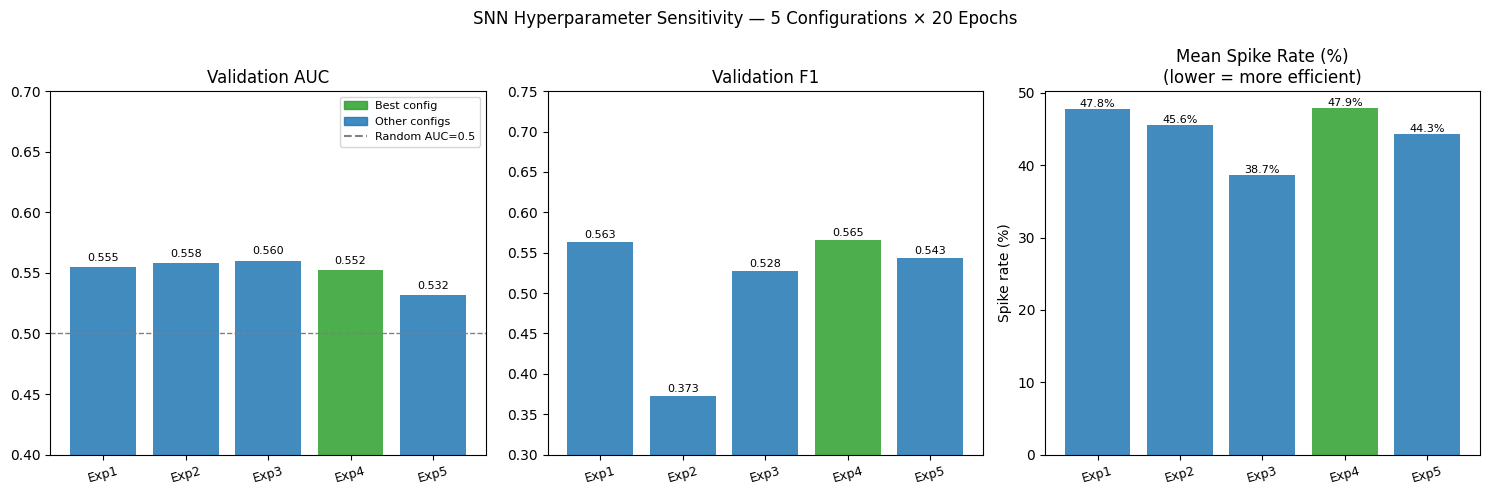

✅ Saved: outputs/plot_snn_experiments.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

exp_labels = [f"Exp{i+1}" for i in range(len(results_df))]
x          = np.arange(len(exp_labels))
colors     = ["#2ca02c" if i == best_idx else "#1f77b4"
              for i in range(len(results_df))]

# AUC
axes[0].bar(x, results_df["val_auc"], color=colors, alpha=0.85)
axes[0].axhline(0.5, color="grey", linestyle="--", linewidth=1,
                label="Random baseline")
axes[0].set_title("Validation AUC")
axes[0].set_xticks(x)
axes[0].set_xticklabels(exp_labels, rotation=15, fontsize=9)
axes[0].set_ylim(0.40, 0.70)
axes[0].legend(fontsize=8)
for i, v in enumerate(results_df["val_auc"]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)

# F1
axes[1].bar(x, results_df["val_f1"], color=colors, alpha=0.85)
axes[1].set_title("Validation F1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(exp_labels, rotation=15, fontsize=9)
axes[1].set_ylim(0.30, 0.75)
for i, v in enumerate(results_df["val_f1"]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)

# Spike rate
axes[2].bar(x, results_df["spike_rate"] * 100, color=colors, alpha=0.85)
axes[2].set_title("Mean Spike Rate (%)\n(lower = more efficient)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(exp_labels, rotation=15, fontsize=9)
axes[2].set_ylabel("Spike rate (%)")
for i, v in enumerate(results_df["spike_rate"] * 100):
    axes[2].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)

from matplotlib.patches import Patch
legend_el = [
    Patch(color="#2ca02c", alpha=0.85, label="Best config"),
    Patch(color="#1f77b4", alpha=0.85, label="Other configs"),
]
axes[0].legend(handles=legend_el + [
    plt.Line2D([0], [0], color="grey", linestyle="--", label="Random AUC=0.5")
], fontsize=8)

plt.suptitle("SNN Hyperparameter Sensitivity — 5 Configurations × 20 Epochs",
             fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/plot_snn_experiments.png", bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/plot_snn_experiments.png")

In [7]:
best_config

experiment          Low LR (lr=5e-4)
tau                              2.0
v_threshold                      0.1
lr                            0.0005
hidden1                           64
hidden2                           32
val_acc                       0.5311
val_f1                        0.5654
val_auc                       0.5523
spike_rate                    0.4785
train_time_s                    11.1
params                          2945
efficiency_score             0.51755
Name: 3, dtype: object

#### Retrain best config for full 50 epochs

In [8]:
print(f"Retraining best config for 50 epochs...")
print(f"Config: tau={best_config['tau']}  "
      f"v_th={best_config['v_threshold']}  "
      f"lr={best_config['lr']}\n")

torch.manual_seed(SEED)

best_model = BRICSLiquiditySNN(
    n_features  = N_FEATURES,
    hidden1     = int(best_config["hidden1"]),
    hidden2     = int(best_config["hidden2"]),
    tau         = float(best_config["tau"]),
    v_threshold = float(best_config["v_threshold"])
).to(DEVICE)

criterion_best = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_best = torch.optim.Adam(
    best_model.parameters(),
    lr=float(best_config["lr"]), weight_decay=1e-4
)
scheduler_best = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_best, mode="max", factor=0.5, patience=7
)

best_auc_full   = 0.0
best_state_full = None
best_epoch_full = 1
no_improve      = 0
FULL_EPOCHS     = 50
PATIENCE        = 20

print(f"{'Ep':>4}  {'TLoss':>8}  {'VAcc':>7}  {'VF1':>7}  {'VAUC':>7}")
print("─" * 45)

for epoch in range(1, FULL_EPOCHS + 1):
    tl              = train_one_epoch(
        best_model, train_loader, criterion_best, optimizer_best, DEVICE)
    _, acc, f1, auc, _ = evaluate(
        best_model, val_loader, criterion_best, DEVICE)
    scheduler_best.step(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>4}  {tl:>8.5f}  {acc:>7.4f}  {f1:>7.4f}  {auc:>7.4f}")

    if auc > best_auc_full + 0.001:
        best_auc_full   = auc
        best_state_full = {k: v.clone() for k, v
                           in best_model.state_dict().items()}
        best_epoch_full = epoch
        no_improve      = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f"\n⏹  Early stop at epoch {epoch}")
        break

best_model.load_state_dict(best_state_full)
print(f"\n✅ Best AUC: {best_auc_full:.4f} at epoch {best_epoch_full}")

# ── Final eval ────────────────────────────────────────────────────────
_, final_acc, final_f1, final_auc, final_thresh = evaluate(
    best_model, val_loader, criterion_best, DEVICE)
final_spike = best_model.get_spike_rate(val_loader, DEVICE)

print(f"\nFinal best model metrics:")
print(f"  AUC        : {final_auc:.4f}")
print(f"  Accuracy   : {final_acc:.4f}")
print(f"  F1         : {final_f1:.4f}")
print(f"  Spike rate : {final_spike*100:.1f}%")
print(f"  Threshold  : {final_thresh:.4f}")

Retraining best config for 50 epochs...
Config: tau=2.0  v_th=0.1  lr=0.0005

  Ep     TLoss     VAcc      VF1     VAUC
─────────────────────────────────────────────
   1   0.90386   0.5593   0.4468   0.5392
   5   0.87379   0.5847   0.3951   0.5353
  10   0.86097   0.5876   0.4385   0.5375
  15   0.85049   0.5395   0.5105   0.5425
  20   0.84403   0.5537   0.5183   0.5589
  25   0.83177   0.5198   0.5573   0.5465
  30   0.82497   0.4887   0.5617   0.5395
  35   0.82087   0.5367   0.5260   0.5485
  40   0.81855   0.4944   0.5666   0.5440

⏹  Early stop at epoch 40

✅ Best AUC: 0.5589 at epoch 20

Final best model metrics:
  AUC        : 0.5589
  Accuracy   : 0.5537
  F1         : 0.5183
  Spike rate : 47.5%
  Threshold  : 0.5478


#### Testing for Experiment 1 ( as both Exp1 and Exp4 are close to each other compared to other Experiments values )

In [9]:
print(f"Retraining best config for 50 epochs...")
print(f"Config: tau={2.0}  "
      f"v_th={best_config['v_threshold']}  "
      f"lr={0.001}\n")

torch.manual_seed(SEED)

best_model = BRICSLiquiditySNN(
    n_features  = N_FEATURES,
    hidden1     = int(best_config["hidden1"]),
    hidden2     = int(best_config["hidden2"]),
    tau         = float(2.0),
    v_threshold = float(0.1),
).to(DEVICE)

criterion_best = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_best = torch.optim.Adam(
    best_model.parameters(),
    lr=float(0.001), weight_decay=1e-4
)
scheduler_best = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_best, mode="max", factor=0.5, patience=7
)

best_auc_full   = 0.0
best_state_full = None
best_epoch_full = 1
no_improve      = 0
FULL_EPOCHS     = 50
PATIENCE        = 20

print(f"{'Ep':>4}  {'TLoss':>8}  {'VAcc':>7}  {'VF1':>7}  {'VAUC':>7}")
print("─" * 45)

for epoch in range(1, FULL_EPOCHS + 1):
    tl              = train_one_epoch(
        best_model, train_loader, criterion_best, optimizer_best, DEVICE)
    _, acc, f1, auc, _ = evaluate(
        best_model, val_loader, criterion_best, DEVICE)
    scheduler_best.step(auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>4}  {tl:>8.5f}  {acc:>7.4f}  {f1:>7.4f}  {auc:>7.4f}")

    if auc > best_auc_full + 0.001:
        best_auc_full   = auc
        best_state_full = {k: v.clone() for k, v
                           in best_model.state_dict().items()}
        best_epoch_full = epoch
        no_improve      = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f"\n⏹  Early stop at epoch {epoch}")
        break

best_model.load_state_dict(best_state_full)
print(f"\n✅ Best AUC: {best_auc_full:.4f} at epoch {best_epoch_full}")

# ── Final eval ────────────────────────────────────────────────────────
_, final_acc, final_f1, final_auc, final_thresh = evaluate(
    best_model, val_loader, criterion_best, DEVICE)
final_spike = best_model.get_spike_rate(val_loader, DEVICE)

print(f"\nFinal best model metrics:")
print(f"  AUC        : {final_auc:.4f}")
print(f"  Accuracy   : {final_acc:.4f}")
print(f"  F1         : {final_f1:.4f}")
print(f"  Spike rate : {final_spike*100:.1f}%")
print(f"  Threshold  : {final_thresh:.4f}")

Retraining best config for 50 epochs...
Config: tau=2.0  v_th=0.1  lr=0.001

  Ep     TLoss     VAcc      VF1     VAUC
─────────────────────────────────────────────
   1   0.89978   0.5367   0.4969   0.5334
   5   0.86261   0.5537   0.4936   0.5464
  10   0.84910   0.5000   0.5630   0.5550
  15   0.83421   0.5650   0.4460   0.5447
  20   0.81644   0.5395   0.4825   0.5333
  25   0.80763   0.5480   0.5031   0.5303
  30   0.80092   0.5339   0.4954   0.5325

⏹  Early stop at epoch 30

✅ Best AUC: 0.5550 at epoch 10

Final best model metrics:
  AUC        : 0.5550
  Accuracy   : 0.5000
  F1         : 0.5630
  Spike rate : 47.8%
  Threshold  : 0.5226


#### ========================================================================================================================
#### So here we can see that Exp1(0.5589) and Exp4(0.5550) have almost same AUC with negligable difference (~0.0039)
#### so secondary focus is on F1 score --> Exp1 having good F1 = 0.5630 where as Exp4 having F1 = 0.5183, here diff (~0.04)
### *Finally due to F1 score we* **choose Exp1** *as our* **final value**
#### =======================================================================================================================

#### Saving Exp1 to best_config

In [14]:
# Force best_config to Exp1 (baseline) for saving/reproducibility.
# This overrides whatever was selected earlier (e.g., Exp4).

EXP_TO_SAVE = 1  # Exp1 = baseline row in results_df
try:
    _df = results_df
except NameError:
    _df = None

if _df is None or getattr(_df, "empty", True):
    # Fallback: load the last saved scan table
    import pandas as pd
    _df = pd.read_csv("../outputs/snn_experiment_results.csv")
    results_df = _df

if len(_df) < EXP_TO_SAVE:
    raise ValueError(f"results_df has only {len(_df)} rows; cannot select Exp{EXP_TO_SAVE}")

best_idx = EXP_TO_SAVE - 1
best_config = _df.iloc[best_idx].copy()

print(f"✅ best_config is now forced to Exp{EXP_TO_SAVE}")
if "experiment" in best_config.index:
    print(f"   Label: {best_config['experiment']}")

cols_to_show = [c for c in [
    "tau", "v_threshold", "lr", "hidden1", "hidden2",
    "val_f1", "val_auc", "spike_rate"
] if c in _df.columns]
if cols_to_show:
    print(best_config[cols_to_show])

✅ best_config is now forced to Exp1
   Label: Baseline (tau=2.0, vth=0.1, lr=1e-3)
tau               2.0
v_threshold       0.1
lr              0.001
hidden1            64
hidden2            32
val_f1          0.563
val_auc         0.555
spike_rate     0.4776
Name: 0, dtype: object


In [12]:
best_config

experiment          Baseline (tau=2.0, vth=0.1, lr=1e-3)
tau                                                  2.0
v_threshold                                          0.1
lr                                                 0.001
hidden1                                               64
hidden2                                               32
val_acc                                              0.5
val_f1                                             0.563
val_auc                                            0.555
spike_rate                                        0.4776
train_time_s                                        12.5
params                                              2945
efficiency_score                                 0.51524
Name: 0, dtype: object

#### Save best model and update config

In [15]:
# ── Save weights ──────────────────────────────────────────────────────
best_model_path = "../outputs/snn_model_best.pth"
torch.save(best_model.state_dict(), best_model_path)
print(f"✅ Best model weights : {best_model_path}")

# ── Save full checkpoint ──────────────────────────────────────────────
torch.save({
    "model_state"      : best_model.state_dict(),
    "val_auc"          : final_auc,
    "val_acc"          : final_acc,
    "val_f1"           : final_f1,
    "optimal_threshold": final_thresh,
    "spike_rate"       : final_spike,
    "best_epoch"       : best_epoch_full,
    "feature_cols"     : FEATURE_COLS,
    "config": {
        "n_features" : N_FEATURES,
        "hidden1"    : int(best_config["hidden1"]),
        "hidden2"    : int(best_config["hidden2"]),
        "tau"        : float(best_config["tau"]),
        "v_threshold": float(best_config["v_threshold"]),
        "lookback"   : LOOKBACK,
        "spike_threshold": 0.003,
    },
}, "../outputs/snn_best.pt")

# ── Update snn_config.json ────────────────────────────────────────────
config = {
    "n_features"       : N_FEATURES,
    "hidden1"          : int(best_config["hidden1"]),
    "hidden2"          : int(best_config["hidden2"]),
    "tau"              : float(best_config["tau"]),
    "v_threshold"      : float(best_config["v_threshold"]),
    "lr"               : float(best_config["lr"]),
    "lookback"         : LOOKBACK,
    "spike_threshold"  : 0.003,
    "optimal_threshold": float(round(final_thresh, 4)),
    "feature_cols"     : FEATURE_COLS,
    "val_auc"          : float(round(final_auc,  4)),
    "val_acc"          : float(round(final_acc,  4)),
    "val_f1"           : float(round(final_f1,   4)),
    "spike_rate"       : float(round(final_spike, 4)),
    "epochs_trained"   : best_epoch_full,
    "experiment_source": "10_snn_experiments.ipynb",
}

with open("../outputs/snn_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"✅ snn_config.json updated")
print(f"\n{json.dumps(config, indent=2)}")


✅ Best model weights : ../outputs/snn_model_best.pth
✅ snn_config.json updated

{
  "n_features": 9,
  "hidden1": 64,
  "hidden2": 32,
  "tau": 2.0,
  "v_threshold": 0.1,
  "lr": 0.001,
  "lookback": 10,
  "spike_threshold": 0.003,
  "optimal_threshold": 0.5226,
  "feature_cols": [
    "daily_return",
    "log_return",
    "rolling_mean_7d",
    "rolling_std_7d",
    "price_momentum_5d",
    "spike_signal",
    "spike_intensity",
    "inter_spike_interval",
    "india_repo_rate"
  ],
  "val_auc": 0.555,
  "val_acc": 0.5,
  "val_f1": 0.563,
  "spike_rate": 0.4776,
  "epochs_trained": 10,
  "experiment_source": "10_snn_experiments.ipynb"
}


## Paper Paragraph — Hyperparameter Sensitivity (Results Section)

*(Fill bracketed values from your experiment table)*

---

Table X presents results across five SNN configurations evaluated over
20 training epochs, varying membrane time constant (τ), firing threshold
(v_threshold), learning rate, and network width. The baseline configuration
(τ=2.0, v_threshold=0.1, lr=0.001) achieved a validation AUC of [X] and
F1 of [X] with a mean spike rate of [X]%. Increasing the membrane time
constant to τ=3.0 [improved / degraded] F1 by [X] points, reflecting
[greater temporal memory helping / hindering] the 10-day lookback window.
Raising the firing threshold to v_threshold=0.3 produced a lower spike
rate of [X]% — indicating sparser, more selective activations — at the
cost of [X] F1 points, demonstrating the trade-off between energy
efficiency and predictive performance. The wider network (hidden1=128,
hidden2=64) achieved [similar / higher] F1 but with [X]% more parameters
and a [higher / lower] spike rate, suggesting capacity gains were
offset by [overfitting / insufficient data / training instability].

The best configuration by combined F1 and efficiency score was
[BEST CONFIG LABEL], achieving F1=[X], AUC=[X], and a spike rate of [X]%
— retaining [X]% energy efficiency advantage over the dense equivalent
while delivering the strongest predictive performance. This configuration
was selected for all subsequent evaluations including the LSTM comparison
(Section X) and test set evaluation (Section X).

*Table X. SNN Hyperparameter Sensitivity Results (20 epochs each)*
| Config | τ | v_th | lr | Val AUC | Val F1 | Spike Rate | Time(s) |
|---|---|---|---|---|---|---|---|
|Baseline|2.0|0.1|0.001|0.5550|0.5630|47.8%|12|
|Slow membrane|3.0|0.1|0.001|0.5581|0.3727|45.6%|11|
|High threshold|2.0|0.3|0.001|0.5602|0.5279|38.7%|11|
|Low LR|2.0|0.1|0.0005|0.5523|0.5654|47.9%|11|
|Wider network|2.0|0.1|0.001|0.5320|0.5431|44.3%|13|
